## Multiple Linear Regression

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [29]:
import pandas as pd
import numpy as np
from sklearn.utils import Bunch

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

# Remove rows with missing total_bedrooms
df = df.dropna()

# Create sklearn-style California Housing features
data = pd.DataFrame({
    "MedInc": df["median_income"],
    "HouseAge": df["housing_median_age"],
    "AveRooms": df["total_rooms"] / df["households"],
    "AveBedrms": df["total_bedrooms"] / df["households"],
    "Population": df["population"],
    "AveOccup": df["population"] / df["households"],
    "Latitude": df["latitude"],
    "Longitude": df["longitude"]
})

# sklearn target is in units of 100,000 dollars
target = df["median_house_value"] / 100000

housing = Bunch(
    data=data.to_numpy(),
    target=target.to_numpy(),
    feature_names=list(data.columns),
    frame=data.assign(MedHouseVal=target)
)

print(housing.data.shape, housing.target.shape)
print(housing.feature_names[0:6])


(20433, 8) (20433,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


In [30]:
california = housing

In [31]:
california.keys()

dict_keys(['data', 'target', 'feature_names', 'frame'])

In [32]:
california.keys()


dict_keys(['data', 'target', 'feature_names', 'frame'])

In [33]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [34]:
# Create a Dataframe

dataset = pd.DataFrame(california.data, columns=california.feature_names)

In [35]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [36]:
# Adding the Dependent Column i.e, price column
dataset['Price'] = california.target

In [37]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [38]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [39]:
dataset.value_counts()

MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  Price
8.3252  41.0      6.984127  1.023810   322.0       2.555556  37.88     -122.23    4.526    1
8.3014  21.0      6.238137  0.971880   2401.0      2.109842  37.86     -122.22    3.585    1
7.2574  52.0      8.288136  1.073446   496.0       2.802260  37.85     -122.24    3.521    1
5.6431  52.0      5.817352  1.073059   558.0       2.547945  37.85     -122.25    3.413    1
3.8462  52.0      6.281853  1.081081   565.0       2.181467  37.85     -122.25    3.422    1
                                                                                          ..
1.5603  25.0      5.045455  1.133333   845.0       2.560606  39.48     -121.09    0.781    1
2.5568  18.0      6.114035  1.315789   356.0       3.122807  39.49     -121.21    0.771    1
1.7000  17.0      5.205543  1.120092   1007.0      2.325635  39.43     -121.22    0.923    1
1.8672  18.0      5.329513  1.171920   741.0       2.123209  39.43     -121

<Axes: >

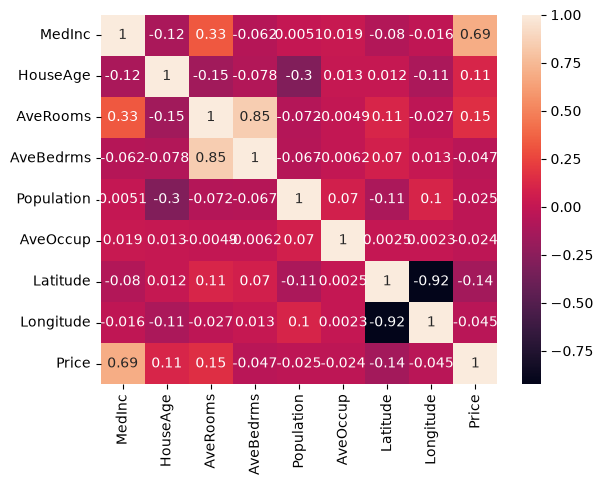

In [40]:
import seaborn as sns
sns.heatmap(dataset.corr(), annot=True)


In [41]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.118278,0.325307,-0.062299,0.005087,0.018894,-0.079626,-0.015550,0.688355
HouseAge,-0.118278,1.000000,-0.153031,-0.077918,-0.295787,0.013258,0.011899,-0.109357,0.106432
AveRooms,0.325307,-0.153031,1.000000,0.848616,-0.071898,-0.004873,0.106423,-0.027307,0.151344
AveBedrms,-0.062299,-0.077918,0.848616,1.000000,-0.066510,-0.006179,0.070025,0.013402,-0.046739
Population,0.005087,-0.295787,-0.071898,-0.066510,1.000000,0.070062,-0.108997,0.100270,-0.025300
AveOccup,0.018894,0.013258,-0.004873,-0.006179,0.070062,1.000000,0.002522,0.002304,-0.023639
Latitude,-0.079626,0.011899,0.106423,0.070025,-0.108997,0.002522,1.000000,-0.924616,-0.144638
Longitude,-0.015550,-0.109357,-0.027307,0.013402,0.100270,0.002304,-0.924616,1.000000,-0.045398
Price,0.688355,0.106432,0.151344,-0.046739,-0.025300,-0.023639,-0.144638,-0.045398,1.000000


## Divide Data into independent and dependent features

In [42]:
X = dataset.iloc[:,:-1] # Independent Features
y = dataset.iloc[:, -1] # Dependent Features



In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [44]:
X_train.shape

(15324, 8)

In [45]:
X_test.shape

(5109, 8)

## Standaridsing the data

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [47]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train the Model

In [48]:
# Train the Model

from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [49]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.13,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.068
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[176.23,169.53,139.02,...,100.79, 35.74, 26.91]"


In [50]:
regression.coef_
#  For each Features we will have Coefficient

array([ 8.49796051e-01,  1.25847119e-01, -2.91840591e-01,  3.41349871e-01,
       -5.15304312e-04, -4.23953015e-02, -8.98833847e-01, -8.66927127e-01])

## Let's do the Prediction

In [51]:
y_pred = regression.predict(X_test)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [54]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.5523675528322454
0.5329396088123698
0.7432143384194396


In [56]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)

print("r2_score : ", score)

r2_score :  0.5795604087518055


In [57]:
# Adjusted R2
adjr2 = 1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 : ", adjr2)


Adjusted R2 :  0.5789008956674946


## Some Assumptions to understad whether our prediction is good or not

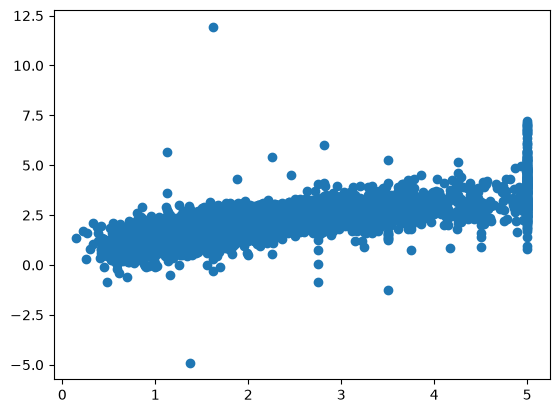

In [58]:
plt.scatter(y_test, y_pred)
plt.show()
plt.figsize = (10,10)

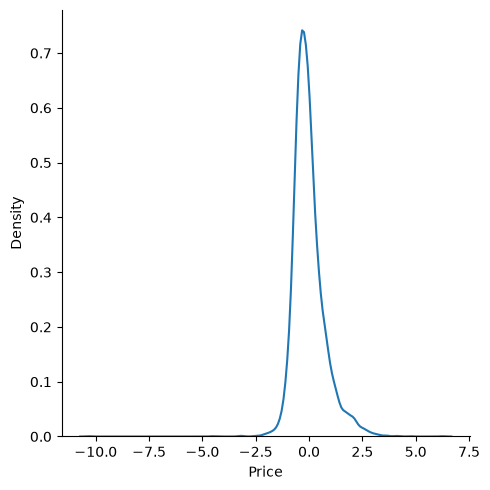

In [59]:
resduals = y_test-y_pred    
sns.displot(resduals, kind="kde")

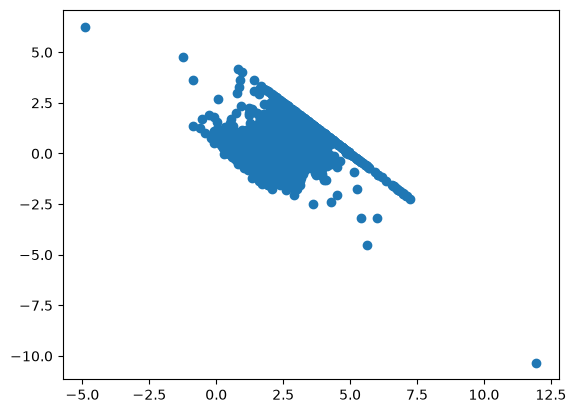

In [64]:
plt.scatter(y_pred, resduals)

## Pickling Concept
- python pickle module is used to serialize and de-serialize a python object structure.what pickle does is it takes a python object structure and converts it into a byte stream.The idea is that the byte stream can be saved on disk or transmitted over a network connection link.
- The inverse operation, un-pickling, is also possible

In [65]:
import pickle
pickle.dump(regression, open('regression.pkl','wb'))

In [67]:
model = pickle.load(open('regression.pkl', 'rb'))

In [70]:
model.predict(X_test)

array([3.37243066, 3.05226268, 3.24592949, ..., 2.24326144, 2.70175968,
       3.08445339], shape=(5109,))